# Evaluation for COLING paper

0. Loading in the results, like ../eval.ipynb
	1. Includes functionality to remove certain runs from the sweep (i.e. minimum reached iterations)
1. Overview table: all results on the full suite of downstream tasks
	1. Word intrusion: the judge's accuracy with its 95% interval, and the diversity of the top words (the only place it is shown)
2. Within our method: parameter comparisons. Statistical comparisons where possible. Compares on the downstream task results and on the judge's word-intrusion accuracy
    1. Tucker vs tt-hybrid: comparison (graphs using the inspect_tucker code) between 4-gram tt and full tucker
    2. subsampling frac: linear in time, but how does the down-stream result change?
    3. population method: is scSoftplus better than countingLog?
    4. n-grams: does it help to increase dimensionality past 3-grams?
    5. rank: higher rank $\rightarrow$  better results? expected for word similarity
    6. dimensions: increasing vocabulary $\rightarrow$  better results? Caveat on the intrusion task: easier task with higher dimensions.
    7. Recap: how do our runs rank on the downstream tasks?
    8. Training seed: how large is the seed noise?
3. Comparison: our standard runs (TT 4-gram, Tucker 3-gram) against comparable baselines.
Representative evaluation: same vocabulary, same latent_rank where possible.
4. Scaling: seconds per iteration.

Everything reports the final model (the last checkpoint). The state training's judge picked (the `best` series) is in appendix B only.

**How this notebook works.** The notebook only calls functions. The code is in `coling_eval.py`, next to this notebook (imported as `ce`). That module builds on `compare.py` (available as `ce.pc`) and, for the training logs, on `tensormet.experimental.inspect_tucker`.

Run it on ampere: the downstream results, the judge's trial records and the training logs are only there.

`../GUIDE.md` (section 7) describes what to report and the caveats of each suite.

## 0. Loading

`ce.load` reads two sets of results and joins them on the run name:

- **Downstream tasks**: the newest complete sweep of the `latest` series (the last checkpoint of every run, i.e. the final model) and the newest `methods` run, both from `downstream_results/`. This follows `../eval.ipynb`.
- **Word intrusion**: the score of the LLM judge per model (Qwen3.5-9B, prompt `default`, k = 4 top words, trial seed 1; chance level 0.20).

| Column | Meaning |
|---|---|
| `judge_acc` | the judge's accuracy: the share of dimensions whose intruder it found |
| `diversity` | diversity of the top words. Loaded, but only shown in section 1.1 |

**Where the downstream tasks come from.** They are the suite that the sparse / interpretable embedding papers share. It goes back to Faruqui et al. (2015); the code is SPINE's (Subramanian et al., 2018), and POLAR (Mathew et al., 2020) reuses it with two more tasks. `downstream_sweep.py` ports each script unchanged.

| Task | First used in this suite | Script ported from | Data read from |
|---|---|---|---|
| `wordsim353` | Faruqui et al. (2015) | SPINE | SPINE |
| `TREC` | Faruqui et al. (2015) | SPINE | POLAR |
| `news_computer`, `news_religion`, `news_sports` | Faruqui et al. (2015) | SPINE | POLAR |
| `np_bracketing` | Faruqui et al. (2015) | SPINE | POLAR |
| `sentiment` | Faruqui et al. (2015) | POLAR | POLAR |
| `discrim_attr` | Mathew et al. (2020) | POLAR | POLAR |
| `word_analogy` (left out, see `SKIP`) | Mathew et al. (2020) | POLAR | gensim |

NP bracketing is the mean over 10 folds, as in POLAR (SPINE scores two folds). Embeddings are scored as they are; POLAR standardises every dimension first.

If a GloVe or word2vec baseline is missing from the newest sweep (a `--no-glove` run), it is taken from the newest sweep that has it; the loader prints this. `glove_nmf_*` rows are left out everywhere (`ce.IGNORE`).

**Leaving runs out**

| Setting | Effect |
|---|---|
| `MIN_ITERS` | drops our runs that stopped before that many iterations |
| `EXCLUDE` | drops every row whose name matches a pattern. A run that stopped early is named `<model>_<iterations reached>` |
| `APPENDIX` | the same, for the quick tests that only the appendix shows |

`S.dropped` lists what was left out and why. For a different cut, load a second suite, e.g. `S250 = ce.load(SERIES, min_iters=250)`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display
import coling_eval as ce

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 60)

# --- Settings ---------------------------------------------------------------

# Which state of every run is evaluated. 'latest' = the last checkpoint, i.e. the final model.
# (The 'best' series is only used in appendix B.)
SERIES = 'latest'

# Our runs that stopped before this many iterations are left out.
# 500 keeps only the runs that finished before walltime; None keeps all.
MIN_ITERS = 500

# Rows left out by name: shell-style patterns, e.g. ['tt_6g_*'].
EXCLUDE = []

# Quick tests: left out of every main result, shown in the appendix only.
APPENDIX = ['*_d200000']



# The summary file of the judge sweep (None: the newest summary_*.csv).
JUDGE_CSV = None

# Section 3: our runs that are compared with the baselines, per latent rank. Fixed in advance,
# not picked on the results: TT 4-gram and Tucker 3-gram at the standard settings.
HEADLINE = {100: ['tt_4g_r100_scSoftPlus_ss0.025', 'tucker_3g_r100_scSoftPlus_ss0.025'],
            300: ['tt_4g_r300_scSoftPlus_ss0.025', 'tucker_3g_r300_scSoftPlus_ss0.025']}

# Section 3: a baseline shares our vocabulary if it knows at least this share of our words.
VOCAB_MIN = 0.5

# Number format of the cost tables (sections 2 and 4).
COST_FORMAT = {'s / iteration': '{:.2f}', 'core parameters': '{:,.0f}'}

# --- Load -------------------------------------------------------------------
S = ce.load(SERIES, min_iters=MIN_ITERS, exclude=[*EXCLUDE, *APPENDIX], judge_csv=JUDGE_CSV)
S.dropped

sweep: sweep_2026-09-30T172843.json (running)
methods: methods_2026-09-24T183147.json (dry-run)
  tt_4g_r100_scSoftPlus_ss1: left out: no checkpoint before the walltime stop (model file at iteration 30)
  not at the table's iteration count, named <model>_<iterations reached>: tucker_4g_r100_countingLogEps_ss0.025_200, tucker_4g_r100_scSoftPlus_ss0.025_d20000_155, tt_4g_r100_scSoftPlus_ss0.1_300, tt_5g_r100_scSoftPlus_ss0.1_245, tt_5g_r300_scSoftPlus_ss0.025_400, tt_6g_r100_scSoftPlus_ss0.1_100, tt_6g_r100_countingLogEps_ss0.025_415, tt_6g_r200_scSoftPlus_ss0.025_275, tt_6g_r300_scSoftPlus_ss0.025_205
kept 23 of our runs and 12 baselines on our words (series latest); 9 rows left out, 12 *_full rows apart
judge: summary_2026-10-02T110542.csv; trials of 34 judged rows


,run,family,reached,checkpoint,reason
model,,,,,
tucker_4g_r100_countingLogEps_ss0.025_200,tucker_4g_r100_countingLogEps_ss0.025,tucker,200,200.pt,reached < 500
tucker_4g_r100_scSoftPlus_ss0.025_d20000_155,tucker_4g_r100_scSoftPlus_ss0.025_d20000,tucker,155,150.pt,reached < 500
tt_4g_r100_scSoftPlus_ss0.1_300,tt_4g_r100_scSoftPlus_ss0.1,tt,300,300.pt,reached < 500
tt_5g_r100_scSoftPlus_ss0.1_245,tt_5g_r100_scSoftPlus_ss0.1,tt,245,225.pt,reached < 500
tt_5g_r300_scSoftPlus_ss0.025_400,tt_5g_r300_scSoftPlus_ss0.025,tt,400,400.pt,reached < 500
tt_6g_r100_scSoftPlus_ss0.1_100,tt_6g_r100_scSoftPlus_ss0.1,tt,100,100.pt,reached < 500
tt_6g_r100_countingLogEps_ss0.025_415,tt_6g_r100_countingLogEps_ss0.025,tt,415,400.pt,reached < 500
tt_6g_r200_scSoftPlus_ss0.025_275,tt_6g_r200_scSoftPlus_ss0.025,tt,275,275.pt,reached < 500
tt_6g_r300_scSoftPlus_ss0.025_205,tt_6g_r300_scSoftPlus_ss0.025,tt,205,200.pt,reached < 500


### Checks

1. Both suites must have scored the same state of each run. The first table lists the runs where they did not (empty = fine).
2. A warning is printed if the judge's trial records do not reproduce its summary.
3. The second table shows our runs that are kept, with their settings.

In [2]:
display(ce.checks(S))

runs_kept = S.df[S.df['family'].isin(ce.OURS)]
runs_kept[['run', *ce.CONFIG, 'reached', 'checkpoint']]

,run,downstream,judge
model,,,


,run,family,ngram,rank,method,ss_frac,dims,tt_rank,random_state,reached,checkpoint
model,,,,,,,,,,,
tucker_3g_r100_scSoftPlus_ss0.025,tucker_3g_r100_scSoftPlus_ss0.025,tucker,3,100,scSoftPlus,0.025,10000,0,1,500,500.pt
tucker_3g_r100_scSoftPlus_ss0.1,tucker_3g_r100_scSoftPlus_ss0.1,tucker,3,100,scSoftPlus,0.100,10000,0,1,500,500.pt
tucker_3g_r100_scSoftPlus_ss1,tucker_3g_r100_scSoftPlus_ss1,tucker,3,100,scSoftPlus,1.000,10000,0,1,500,500.pt
tucker_3g_r100_countingLog_ss0.025,tucker_3g_r100_countingLog_ss0.025,tucker,3,100,countingLog,0.025,10000,0,1,500,500.pt
tucker_3g_r100_countingLogEps_ss0.025,tucker_3g_r100_countingLogEps_ss0.025,tucker,3,100,countingLogEps,0.025,10000,0,1,500,500.pt
tucker_3g_r200_scSoftPlus_ss0.025,tucker_3g_r200_scSoftPlus_ss0.025,tucker,3,200,scSoftPlus,0.025,10000,0,1,500,500.pt
tucker_3g_r300_scSoftPlus_ss0.025,tucker_3g_r300_scSoftPlus_ss0.025,tucker,3,300,scSoftPlus,0.025,10000,0,1,500,500.pt
tucker_4g_r100_scSoftPlus_ss0.025,tucker_4g_r100_scSoftPlus_ss0.025,tucker,4,100,scSoftPlus,0.025,10000,0,1,500,500.pt
tucker_4g_r100_countingLog_ss0.025,tucker_4g_r100_countingLog_ss0.025,tucker,4,100,countingLog,0.025,10000,0,1,500,500.pt


## 1. Overview

Every row on our words: our runs, GloVe / word2vec and the interpretable methods (the baselines restricted to our 10k words).

| Column | Meaning |
|---|---|
| task columns | every downstream task except those in `SKIP` |
| `downstream_average` | their mean (– if a task is missing). Note that it averages accuracies with WordSim-353's Spearman ρ |
| `judge_acc` | the judge's accuracy on word intrusion |
| `mean rank` | mean rank over the downstream tasks (1 = best) |
| `mean rank, + judge` | the same with `judge_acc` as one more ranked column (– for a row the judge did not score) |
| `latent_rank` | our rank, or the number of dimensions of a baseline |

Rows are sorted by `downstream_average`, best first.

The `d20000` runs have 20k words, so they cover more of each task than the rows restricted to our 10k words (see section 2.6).

The baselines on their own whole vocabulary are in `S.full`. They are never compared with our runs.

In [3]:
ce.overview(S)

,kind,latent_rank,sentiment,TREC,discrim_attr,news_computer,news_religion,news_sports,np_bracketing,wordsim353,downstream_average,judge_acc,mean rank,"mean rank, + judge"
model,,,,,,,,,,,,,,
spine_w2v,interpretable: SPINE,1000,0.769,0.914,0.650,0.772,0.808,0.888,0.756,0.635,0.774,0.795,5.9,8.1
w2v,dense,300,0.784,0.816,0.647,0.743,0.838,0.863,0.778,0.677,0.768,–,6.1,–
spine_glove,interpretable: SPINE,1000,0.748,0.886,0.605,0.777,0.796,0.877,0.745,0.650,0.761,0.731,10.0,11.9
spowv_w2v,interpretable: SPOWV,1000,0.783,0.800,0.626,0.816,0.821,0.893,0.713,0.604,0.757,0.467,10.1,12.4
nnse_1000,interpretable: NNSE,1000,0.740,0.914,0.588,0.781,0.826,0.864,0.721,0.592,0.753,0.874,9.0,9.6
spowv_glove,interpretable: SPOWV,1000,0.754,0.794,0.606,0.766,0.828,0.877,0.698,0.675,0.750,0.394,11.6,14.0
glove_300,dense,300,0.759,0.796,0.618,0.746,0.840,0.861,0.739,0.539,0.737,0.360,12.0,14.4
polar_w2v_k500,interpretable: POLAR,500,0.772,0.812,0.598,0.721,0.835,0.864,0.740,0.517,0.732,0.546,12.4,14.2
sinr_bnc,interpretable: SINr,1431,0.726,0.786,0.646,0.752,0.816,0.809,0.709,0.550,0.724,0.475,14.1,15.9


### 1.1 Word intrusion per row

One row per model that the judge scored.

- `dims judged`: the number of dimensions the judge saw (one trial per dimension).
- `judge_acc`, with its 95% Wilson interval. The interval is the uncertainty of one model's score from its own trials (about ±0.07 at 100 dimensions). It is not the variation over training seeds; section 2.8 measures that.
- `diversity` = distinct top words / (dimensions × k). It is low when many dimensions share their top words, which makes the intruder easier to spot. Diversity enters no score and no test; this table is the only place where it is shown.
- `short dims`: dimensions with fewer than k positive words among ours (this happens for sparse baselines).

In [4]:
ce.intrusion_table(S)

,kind,latent_rank,dims judged,judge_acc,95% CI low,95% CI high,diversity,short dims
model,,,,,,,,
glove_100,dense,100,100,0.440,0.347,0.538,0.925,0
glove_300,dense,300,300,0.360,0.308,0.416,0.829,0
nnse_300,interpretable: NNSE,300,300,0.827,0.780,0.865,0.978,0
nnse_1000,interpretable: NNSE,1000,1000,0.874,0.852,0.893,0.924,0
polar_glove_k500,interpretable: POLAR,500,500,0.562,0.518,0.605,0.917,0
polar_w2v_k500,interpretable: POLAR,500,500,0.546,0.502,0.589,0.920,0
sinr_bnc,interpretable: SINr,1431,1431,0.475,0.449,0.501,0.568,0
spine_w2v,interpretable: SPINE,1000,1000,0.795,0.769,0.819,0.742,0
spine_glove,interpretable: SPINE,1000,1000,0.731,0.703,0.758,0.689,0


## 2. Within our method

**Matched sets.** The effect of a setting is measured on runs that are equal in every other setting (family, n-gram, rank, population method, subsample fraction, vocabulary `dims`, TT bond dimension). Such a group of runs is a *matched set*. It is named like a run, with `*` for the setting that varies: `tt_4g_r*_scSoftPlus_ss0.025` is the rank series of the standard model.

**What `ce.report` shows per factor**

1. the matched runs (best per set in bold),
2. the tests on the downstream tasks,
3. the tests on the judge's accuracy,
4. a figure of the scores per level, and a figure of the paired differences.

**Tests**

| Suite | Unit | Trend (≥ 3 ordered levels) | Two levels (step or contrast) | Effect size |
|---|---|---|---|---|
| downstream tasks (all but `SKIP`) | the task; the score of a level is its mean over the matched sets (Demšar 2006) | Page's L | Wilcoxon signed-rank over the tasks | trend: ρ between level and score; two levels: rank-biserial r. Both lie between −1 and +1 |
| judge accuracy (`judge_acc`) | the judge's trial, one per dimension | stratified Cochran–Armitage (strata = matched sets) | Cochran–Mantel–Haenszel | Δ accuracy |

- *Ordered* factors (n-gram, rank, `dims`, subsample fraction, bond dimension) are tested between neighbouring levels (a "step"), plus one trend test over the largest number of levels that some sets share.
- *Unordered* factors (Tucker vs TT, population method) are tested as the contrasts listed in `ce.CONTRASTS`.
- Δ is always the later level − the earlier one.
- Holm's correction is applied per suite within a factor.
- All tests are two-sided: no direction was fixed before the results were seen (`ce.EXPECTED` is empty).

**Reading the tables.** Every test column starts with its suite: `downstream …` or `judge acc …`. The `reading` column puts the Holm-corrected p at 0.05 into words (– = no test).

`ce.directions(S, R)` additionally shows both one-sided p-values of a factor next to the two-sided one and, for three levels or more, an order-free test (used in 2.4). Read these as exploratory.

**Read before trusting a result**

- There is one run per setting, so seed variance is in none of the tests (section 2.8 measures it). A p-value says whether the tasks (or trials) agree on a direction *for these runs*.
- With 8 tasks the smallest two-sided Wilcoxon p is 2/2⁸ ≈ 0.008. "No evidence" is not "no effect": read the effect sizes and the figures.
- The classifier tasks are unseeded (noise of about 0.01, up to 0.04 on the newsgroup tasks). `better` / `worse` therefore count only differences beyond `ce.TOL`.
- The judge's task gets easier when many dimensions share their top words (section 1.1). Compare accuracies with that in mind.
- Runs left out in section 0 are missing here too (`S.dropped`).

### 2.1 Tucker vs Tucker-TT hybrid

Full Tucker against the hybrid (the core stored as a tensor train with bond dimension 100), on the same 4-gram tensor and with every other setting equal.

,,,downstream sets,downstream tasks,downstream mean Δ,downstream tasks better,downstream tasks worse,downstream statistic,downstream effect,downstream p (Holm),downstream reading,H1
factor,test,levels,,,,,,,,,,
family,contrast,tucker → tt,2,8,+0.005,6,1,8.00,+0.556,0.1953,no evidence,two-sided


,,,judge acc sets,judge acc trials,judge acc by level,judge acc Δ,judge acc z,judge acc p (Holm),judge acc reading,H1
factor,test,levels,,,,,,,,
family,contrast,tucker → tt,2,400,0.870 → 0.870,-0.000,0.00,1.0000,no evidence,two-sided


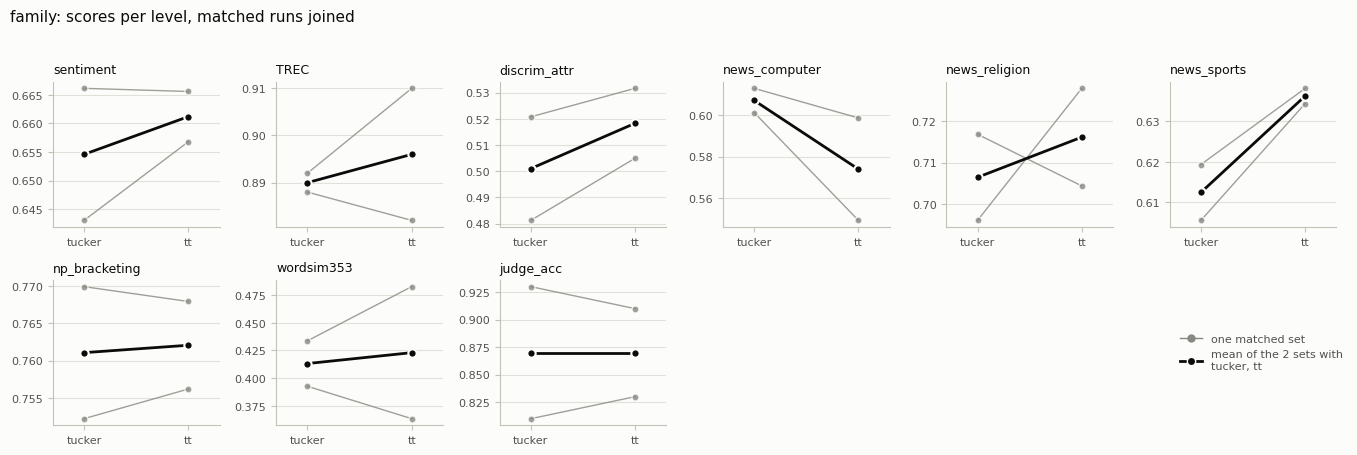

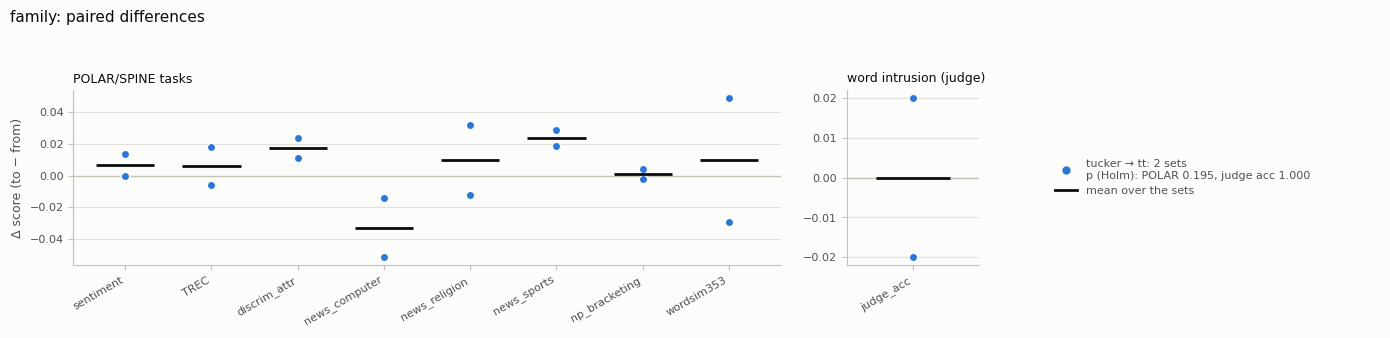

In [5]:
R_family = ce.report(S, 'family')

**Training curves and cost**

- The curves show the reconstruction error. They are read from the runs' logs by `inspect_tucker.load_metrics` and stitched together over resumes (`resume_chain`). The semantic checks made during training, which pick the `best` state, are in appendix B.
- The table gives the cost: seconds per iteration and the size of the core. Seconds per iteration is the median of the iteration times in the run's log. Runs shared GPUs and ran on different hardware, so read it as a rough number.

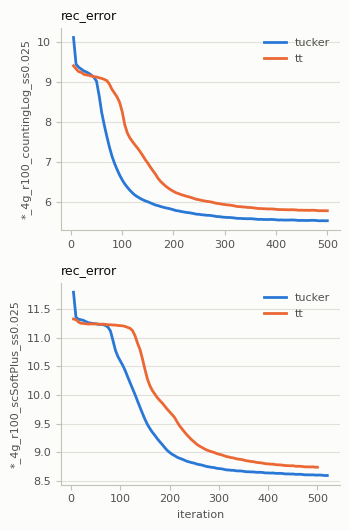

In [6]:
ce.plot_curves(S, ce.curve_groups(S, R_family), keys=ce.CURVE_KEYS, smooth=None)
ce.cost(S, 'family').style.format(COST_FORMAT, na_rep='–')

The hybrid has one setting of its own: the bond dimension (`tt_rank`, shown as `b<n>` below). 100 is the default used above.

In [7]:
R_bond = ce.report(S, 'tt_rank')
ce.plot_curves(S, ce.curve_groups(S, R_bond))

tt_rank: no matched sets among the runs kept
no runs to plot


### 2.2 Subsampling fraction

**Time.** The time per iteration should grow linearly with `ss_frac`. The first table gives the seconds per iteration (the median of the iteration times in each run's log) for every run, also the ones that stopped early. The figure shows them per matched set, and the last table gives the linear fit per set: time = fixed + per_unit × `ss_frac`.

**Scores.** Then the scores, on the runs that were kept (`S.dropped` lists the ones that stopped early).

**Same checkpoint.** A run with a larger `ss_frac` is slower and stopped earlier. The last cell therefore repeats the comparison with every run of a matched set cut to the same iteration (`downstream_sweep.py --series same`): the highest iteration that all runs of the set have a checkpoint of. For example, `tt_4g_r100_scSoftPlus_ss0.025` is taken at iteration 300, where its `ss0.1` sibling stopped. These rows are named `<model>_<iteration>`, and `MIN_ITERS` does not apply. This series has our runs and the downstream tasks only: the judge did not score these checkpoints, so its table is empty.

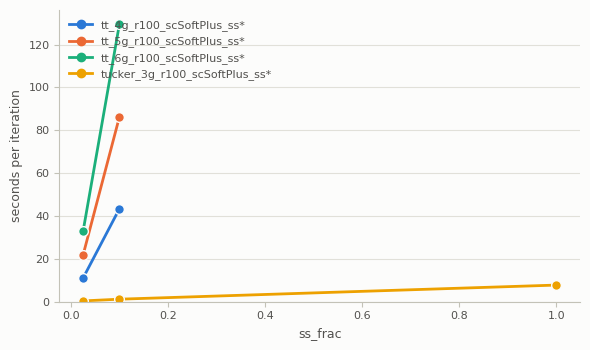

,levels,fixed (s),per unit (s),R²
tt_4g_r100_scSoftPlus_ss*,2.0,0.230369,431.862949,NaN
tt_5g_r100_scSoftPlus_ss*,2.0,0.237756,860.692437,NaN
tt_6g_r100_scSoftPlus_ss*,2.0,0.527400,1291.227854,NaN
tucker_3g_r100_scSoftPlus_ss*,3.0,0.310600,7.467465,0.999075


In [8]:
time_by_ss = ce.cost(S, 'ss_frac')
display(time_by_ss.style.format(COST_FORMAT, na_rep='–'))

# the figure, then the linear fit per matched set
ce.plot_time(time_by_ss)

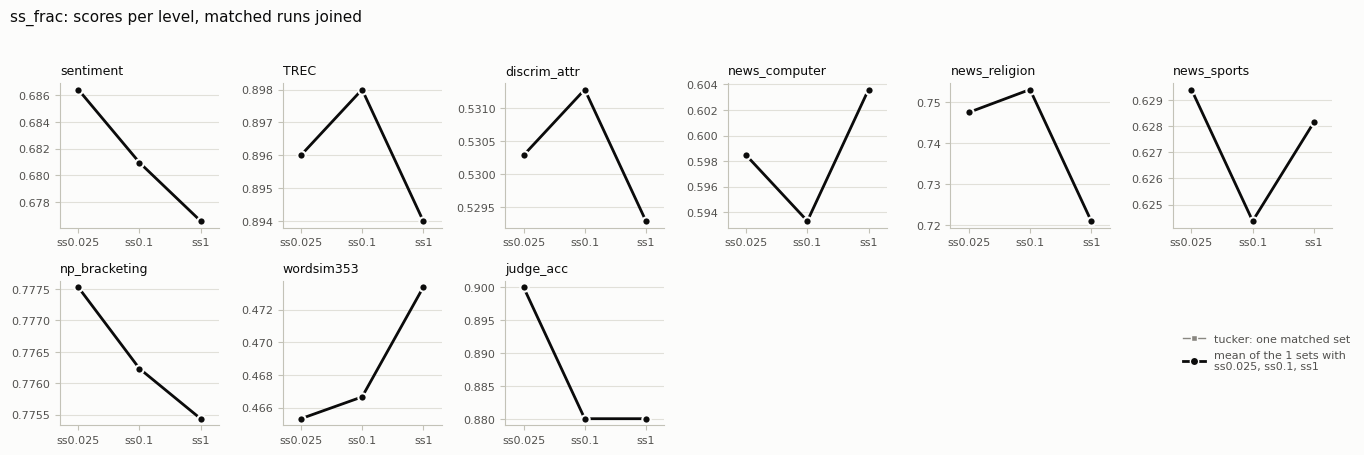

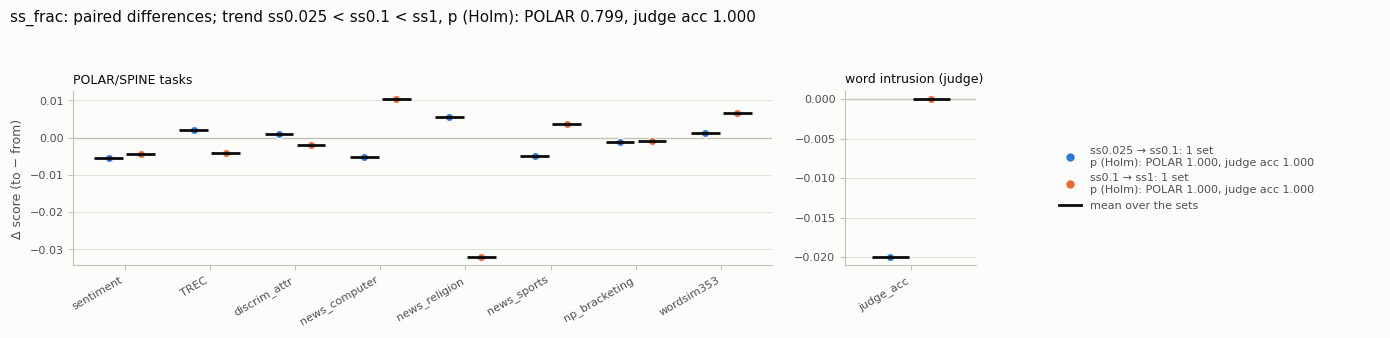

In [9]:
R_ss = ce.report(S, 'ss_frac')

In [10]:
# The same comparison, every run of a matched set at the same checkpoint (see "Same checkpoint" above)
S_same = ce.load('same', exclude=[*EXCLUDE, *APPENDIX], skip=SKIP, judge_csv=JUDGE_CSV)
R_ss_same = ce.report(S_same, 'ss_frac')

NameError: name 'SKIP' is not defined

### 2.3 Population method

Is scSoftPlus better than countingLog and countingLogEps? The contrasts tested are the ones in `ce.CONTRASTS['method']`. Δ = the second method − the first, so a positive Δ in `countingLog → scSoftPlus` favours scSoftPlus.

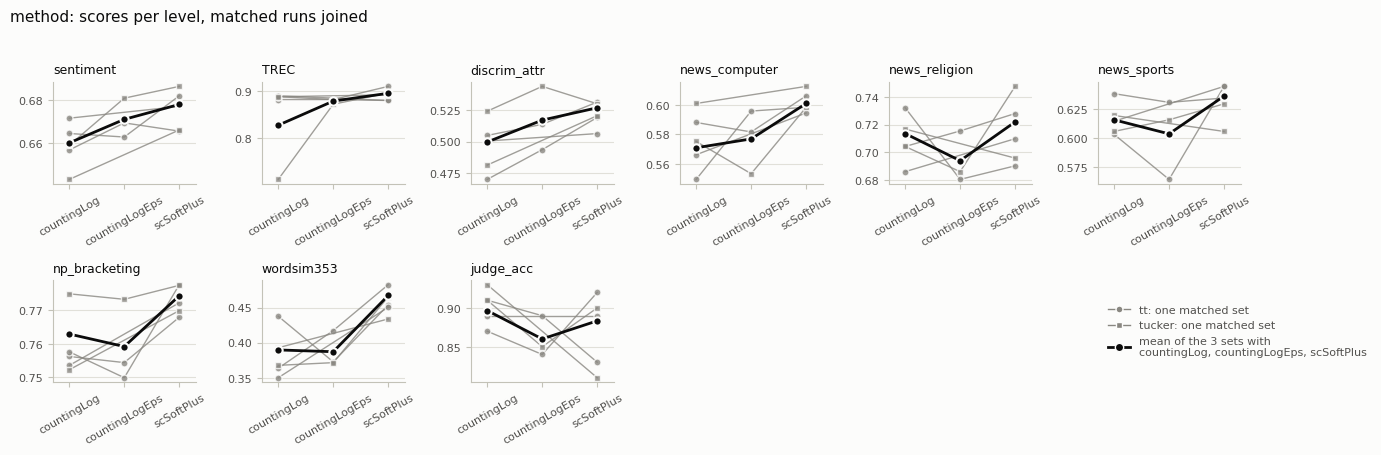

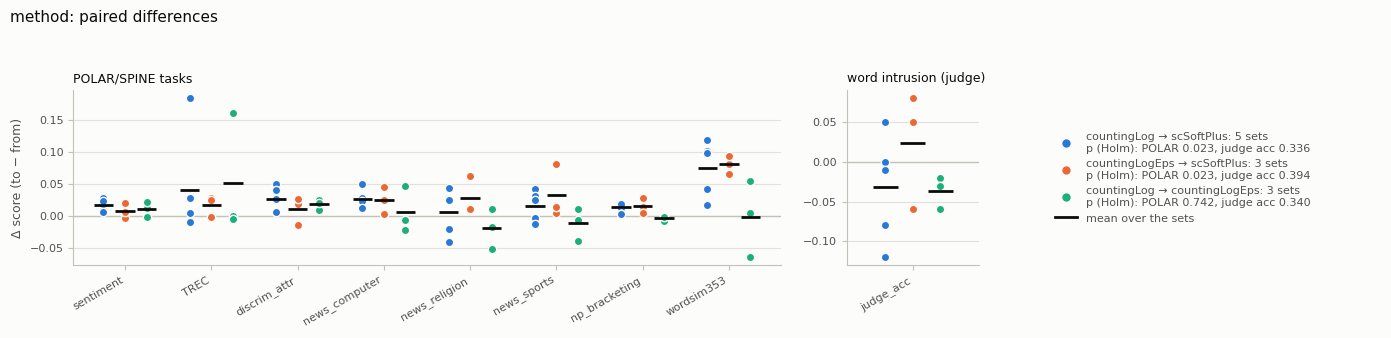

In [44]:
R_method = ce.report(S, 'method')

### 2.4 n-grams

Does a longer n-gram (a tensor of higher order) help?

A step compares runs of one family. Tucker was run on 3- and 4-grams and TT on 4- to 6-grams, so the step 3 → 4 is Tucker only and the steps 4 → 5 → 6 are TT only. The trend test takes the levels that the most sets share.

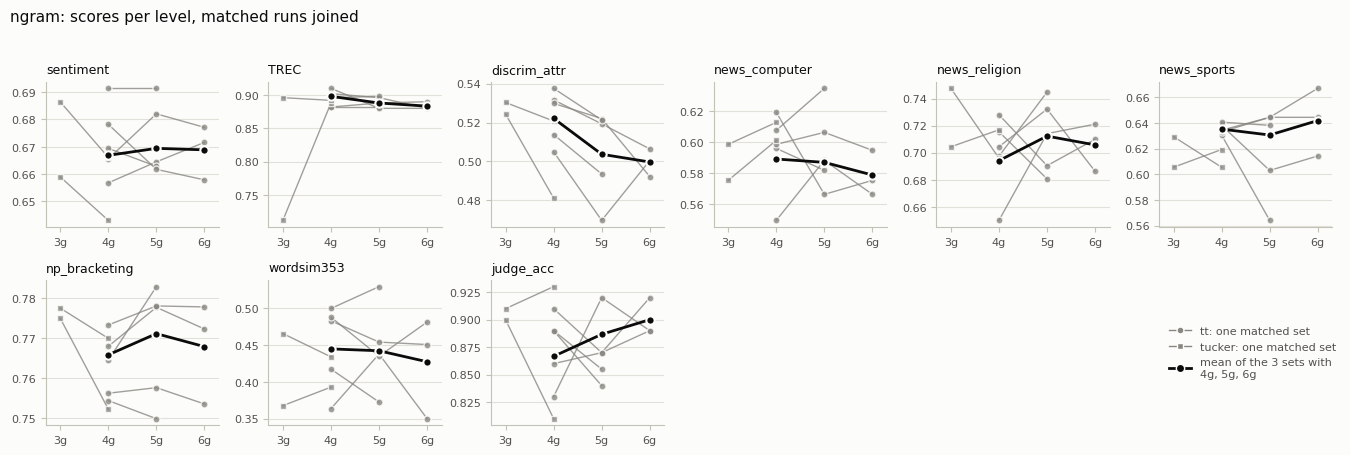

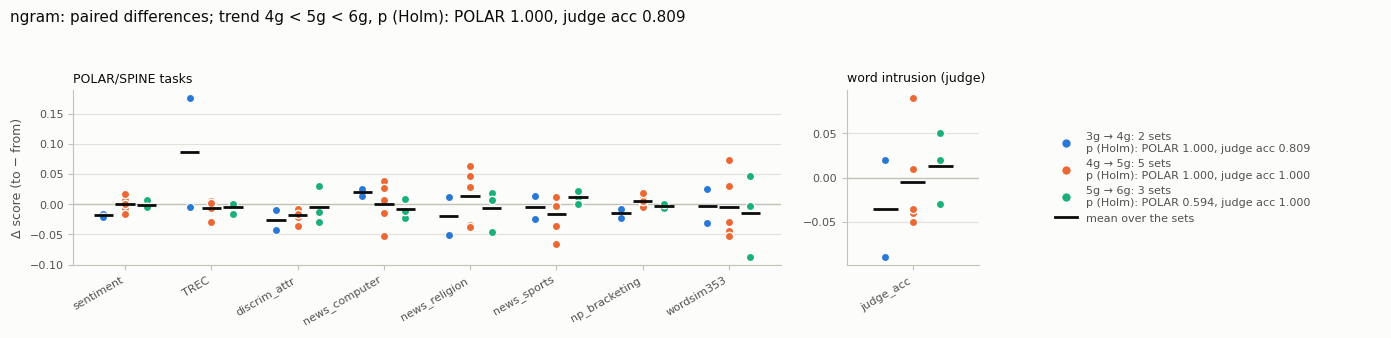

In [45]:
R_ngram = ce.report(S, 'ngram')

**One-sided and order-free tests.** No direction is expected for the n-gram order, so the tests above are two-sided: they find a change in either direction. The first table below shows both one-sided tests next to the two-sided one (Holm per column). They are exploratory, since no direction was fixed before the results were seen.

The trend test also assumes a monotone order (4g < 5g < 6g), so it misses a peak in the middle (e.g. 5-grams being best). The second table gives order-free tests, which only ask whether the levels differ, in any pattern: Friedman's test on the downstream tasks and the generalised CMH test on the judge's accuracy.

In [46]:
ce.directions(S, R_ngram)

,,units,statistic,df,Kendall's W,p
suite,test,,,,,
downstream,Friedman,8 tasks,1.75,2,0.109,0.4169
judge acc,generalised CMH,900 trials,1.65,2,–,0.4388


### 2.5 Rank

Does a higher rank (more dimensions) help?

One would expect the downstream tasks to get better with more dimensions and the judge's task to get harder. But these directions were only written down after `../eval.ipynb` (section 9) had shown the rank results. The tests are therefore two-sided, like everywhere else; `ce.directions` shows both one-sided p-values as well (exploratory).

The rank is also the `latent_rank` on which section 3 matches the baselines.

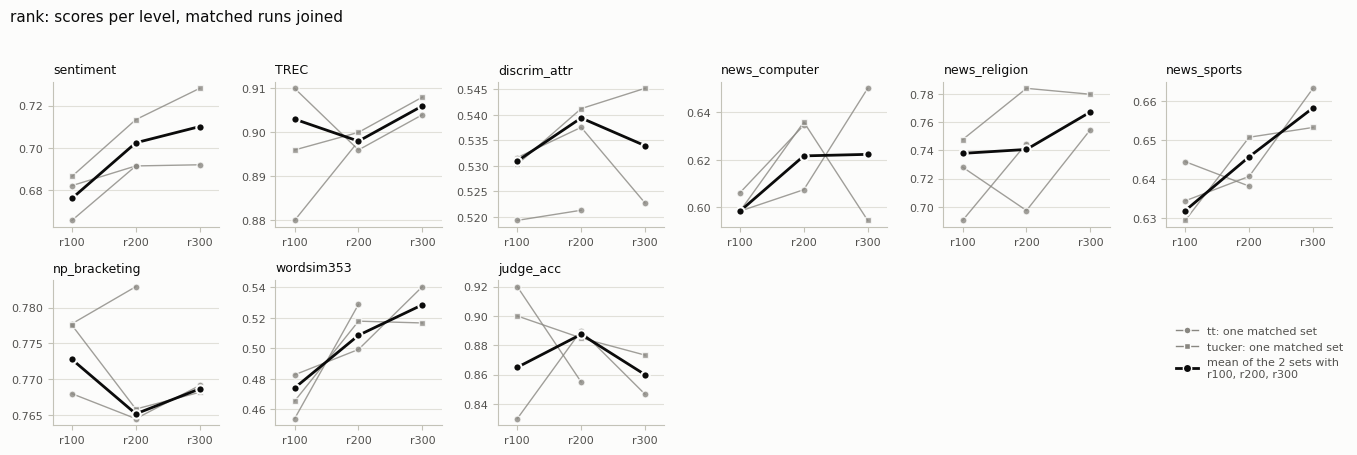

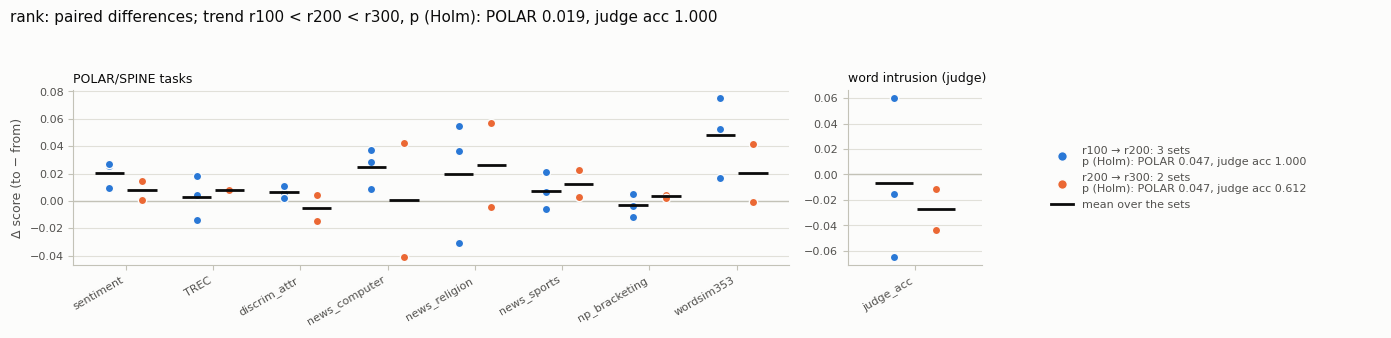

,,units,statistic,df,Kendall's W,p
suite,test,,,,,
downstream,Friedman,8 tasks,7.75,2,0.484,0.0208
judge acc,generalised CMH,1200 trials,1.66,2,–,0.4367


In [47]:
R_rank = ce.report(S, 'rank')
ce.directions(S, R_rank)

### 2.6 Vocabulary (`dims`)

Does a larger vocabulary (words per mode: 10k → 20k) help? The 200k-word run is a quick test: it is left out here and shown in appendix A only.

Two caveats:

- A larger vocabulary covers more of each task (see the coverage table below), so part of a change on the downstream tasks is coverage, not quality.
- The judge ranks each dimension over the model's own words. A 20k-word model therefore gets other top words and other intruders than a 10k-word model, so an effect of `dims` on `judge_acc` is not a like-for-like comparison.

,,,downstream sets,downstream tasks,downstream mean Δ,downstream tasks better,downstream tasks worse,downstream statistic,downstream effect,downstream p (Holm),downstream reading,H1
factor,test,levels,,,,,,,,,,
dims,step,"10,000 → 20,000",3,8,-0.003,2,3,12.00,-0.333,0.4609,no evidence,two-sided


,,,judge acc sets,judge acc trials,judge acc by level,judge acc Δ,judge acc z,judge acc p (Holm),judge acc reading,H1
factor,test,levels,,,,,,,,
dims,step,"10,000 → 20,000",3,600,0.880 → 0.883,+0.003,0.13,0.8993,no evidence,two-sided


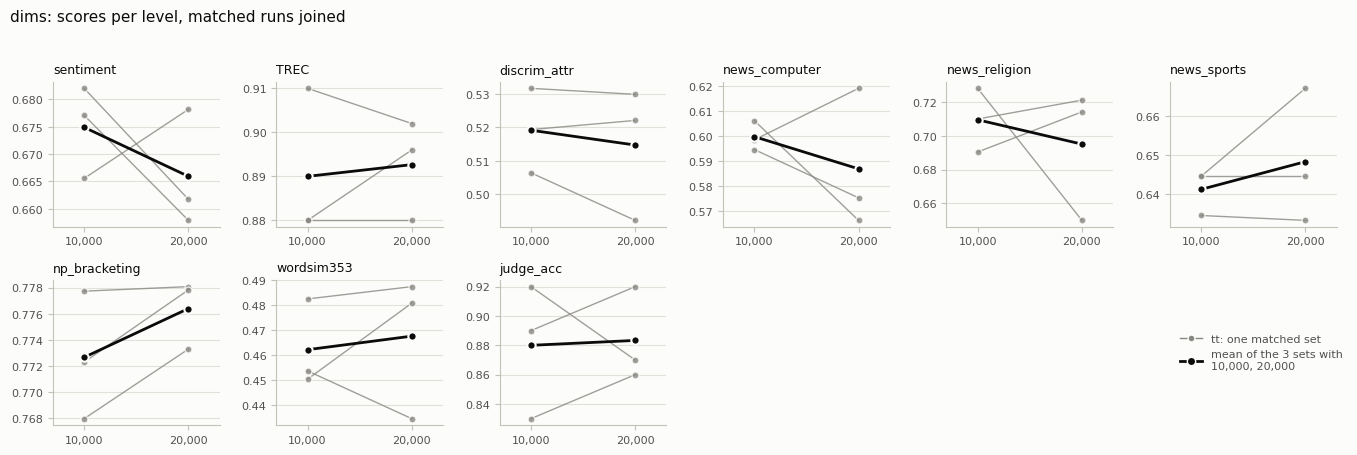

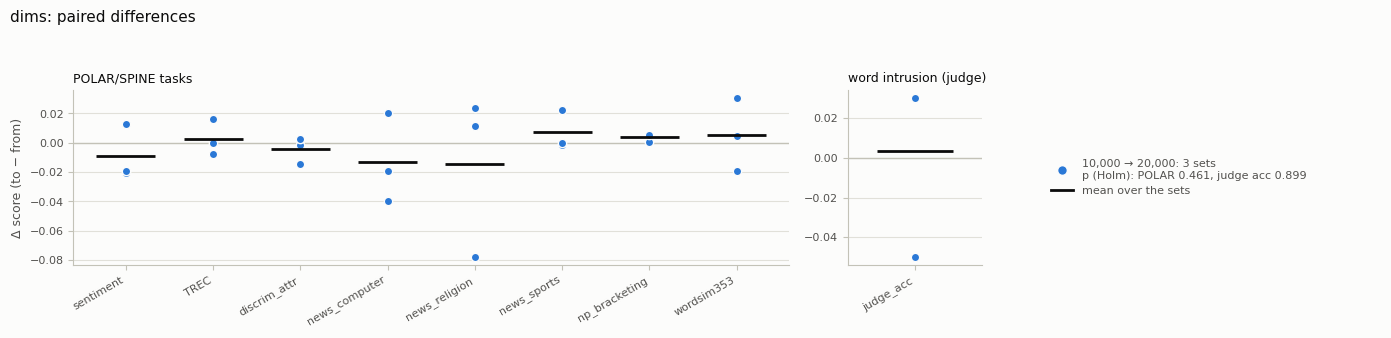

,sentiment,TREC,discrim_attr,news_computer,news_religion,news_sports,np_bracketing,wordsim353
"10,000 → 20,000",+0.048,+0.044,+0.285,+0.030,+0.030,+0.041,+0.038,+0.165


In [48]:
R_dims = ce.report(S, 'dims')
ce.coverage_shift(S, R_dims)

### 2.7 Recap: how do our runs rank on the downstream tasks?

Our runs that were kept, sorted by `downstream_average` (best first), with their mean rank over the downstream tasks (1 = best, ties averaged).

- **Friedman's test** asks whether the runs differ at all.
- **Nemenyi's critical difference (CD)** marks with ✓ the runs that are not significantly behind the best mean rank (Demšar 2006). With 8 tasks and some 25 runs the CD is wide: read ✓ as "cannot be told apart from the best mean rank".

The top runs lie within the seed noise of section 2.8. This ranking therefore picks no run for section 3: the runs compared there were fixed in advance.

In the first table the judge's accuracy is shown but not ranked. The second table ranks it as one more column.

Friedman over 8 columns and 25 runs: chi2 = 85.1, p = 9.2e-09; Nemenyi CD (alpha 0.05) = 13.5 ranks


,family,ngram,rank,method,ss_frac,dims,tt_rank,reached,mean rank,#1,mean score,downstream_average,judge_acc,within CD
model,,,,,,,,,,,,,,
tucker_3g_r200_scSoftPlus_ss0.025,tucker,3,200,scSoftPlus,0.025,10000,0,500,4.88,1,0.689,0.689,0.885,✓
tt_4g_r300_scSoftPlus_ss0.025,tt,4,300,scSoftPlus,0.025,10000,100,500,4.88,2,0.687,0.687,0.847,✓
tucker_3g_r300_scSoftPlus_ss0.025,tucker,3,300,scSoftPlus,0.025,10000,0,500,5.56,2,0.687,0.687,0.873,✓
tt_5g_r200_scSoftPlus_ss0.025,tt,5,200,scSoftPlus,0.025,10000,100,500,6.12,1,0.680,0.680,0.855,✓
tt_4g_r200_scSoftPlus_ss0.025,tt,4,200,scSoftPlus,0.025,10000,100,500,9.69,0,0.667,0.667,0.890,✓
tucker_3g_r100_scSoftPlus_ss0.025,tucker,3,100,scSoftPlus,0.025,10000,0,500,9.06,0,0.666,0.666,0.900,✓
tucker_3g_r100_scSoftPlus_ss0.1,tucker,3,100,scSoftPlus,0.1,10000,0,500,9.69,0,0.665,0.665,0.880,✓
tt_4g_r100_scSoftPlus_ss0.025,tt,4,100,scSoftPlus,0.025,10000,100,500,9.94,1,0.665,0.665,0.830,✓
tucker_3g_r100_scSoftPlus_ss1,tucker,3,100,scSoftPlus,1,10000,0,500,10.69,0,0.663,0.663,0.880,✓


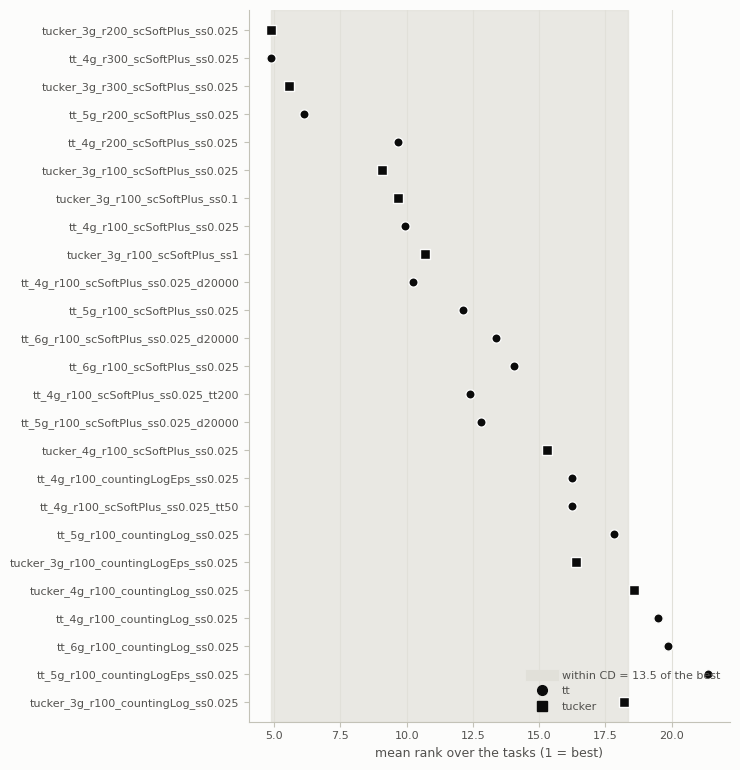

In [49]:
ranking, critical_difference = ce.ranking(S)
display(ce.style_ranking(ranking))
ce.plot_ranking(ranking, critical_difference)

In [50]:
# The same, with the judge's accuracy as one more ranked column; the first 10 rows.
# Runs that the judge did not score drop out.
ranking_with_judge, cd_with_judge = ce.ranking(S, cols=[*ce.tasks(), 'judge_acc'])
ce.style_ranking(ranking_with_judge.head(10))

Friedman over 9 columns and 25 runs: chi2 = 74.0, p = 5.4e-07; Nemenyi CD (alpha 0.05) = 12.7 ranks


,family,ngram,rank,method,ss_frac,dims,tt_rank,reached,mean rank,#1,mean score,downstream_average,judge_acc,within CD
model,,,,,,,,,,,,,,
tucker_3g_r200_scSoftPlus_ss0.025,tucker,3,200,scSoftPlus,0.025,10000,0,500,5.56,1,0.710,0.689,0.885,✓
tt_4g_r300_scSoftPlus_ss0.025,tt,4,300,scSoftPlus,0.025,10000,100,500,6.67,2,0.705,0.687,0.847,✓
tucker_3g_r300_scSoftPlus_ss0.025,tucker,3,300,scSoftPlus,0.025,10000,0,500,6.50,2,0.707,0.687,0.873,✓
tt_5g_r200_scSoftPlus_ss0.025,tt,5,200,scSoftPlus,0.025,10000,100,500,7.44,1,0.699,0.680,0.855,✓
tt_4g_r200_scSoftPlus_ss0.025,tt,4,200,scSoftPlus,0.025,10000,100,500,9.56,0,0.692,0.667,0.890,✓
tucker_3g_r100_scSoftPlus_ss0.025,tucker,3,100,scSoftPlus,0.025,10000,0,500,8.72,0,0.692,0.666,0.900,✓
tucker_3g_r100_scSoftPlus_ss0.1,tucker,3,100,scSoftPlus,0.1,10000,0,500,10.00,0,0.689,0.665,0.880,✓
tt_4g_r100_scSoftPlus_ss0.025,tt,4,100,scSoftPlus,0.025,10000,100,500,11.50,1,0.683,0.665,0.830,✓
tucker_3g_r100_scSoftPlus_ss1,tucker,3,100,scSoftPlus,1,10000,0,500,10.89,0,0.687,0.663,0.880,✓


**Every test of this section in one table.**

In [51]:
section2_results = [R_family, R_bond, R_ss, R_method, R_ngram, R_rank, R_dims]
ce.summary(section2_results)

### 2.8 Training seed

How much does the training seed (`random_state`: the initial factors and the subsample windows) move the scores?

The standard 4-gram setting was trained with seeds 1, 2 and 3 for both families. The Tucker replicates stopped at 195 and 185 iterations (walltime) and are cut by `MIN_ITERS`, so only the TT set is shown. The replicates are left out of everything above (one run per setting). Here they are put back, as far as the cuts of section 0 keep them (`MIN_ITERS`, `EXCLUDE`, `APPENDIX`).

The result of this section is the **size** of the seed noise, not a p-value. `ce.seed_report` shows, in this order:

1. **The runs per seed.** A *replicate set* is a group of runs that are equal in every setting but the seed.
2. **The noise per column.** The SD over the seeds (pooled over the sets), next to the SD over our seed-1 runs on our words. `band` = 2·√2·pooled SD: about the largest difference that two seeds of one setting show.
3. **Sections 2.1–2.6 against the band.** For every change tested there: the share of its matched pairs that differ by more than `band`. Near 0 means that the change is no larger than what a new seed does.
4. **A check on the judge.** Do the seeds differ by more than the judge's own trial noise? (Generalised CMH on the accuracy; Holm over the sets.) "Within judge noise" says that these trials cannot tell the seeds apart, not that the seed has no effect.
5. **Figures.** The scores per seed, and the training curves (from the logs, through `inspect_tucker`).

Read before trusting a result: three seeds give an SD with 2 degrees of freedom (one set). The downstream classifiers are unseeded, so their re-scoring noise is inside the seed SD: it is an upper bound on the effect of the seed itself.

,SD tt_4g_r100_scSoftPlus_ss0.025_rs*,pooled SD,SD over settings,seed / settings,band
sentiment,0.0060,0.0060,0.0199,30%,0.0171
TREC,0.0136,0.0136,0.0395,34%,0.0385
discrim_attr,0.0198,0.0198,0.0200,99%,0.0561
news_computer,0.0097,0.0097,0.0273,35%,0.0273
news_religion,0.0351,0.0351,0.0321,109%,0.0992
news_sports,0.0091,0.0091,0.0223,41%,0.0256
np_bracketing,0.0035,0.0035,0.0097,36%,0.0098
wordsim353,0.0491,0.0491,0.0575,85%,0.1387
downstream_average,0.0109,0.0109,0.0208,52%,0.0308
judge_acc,0.0321,0.0321,0.0311,103%,0.0909


,,,judge acc trials,judge acc by seed,judge acc statistic,judge acc p (Holm),judge acc reading
factor,test,levels,,,,,
random_state,seeds,tt_4g_r100_scSoftPlus_ss0.025_rs*,300,0.830 · 0.840 · 0.890,1.65,0.4392,within judge noise


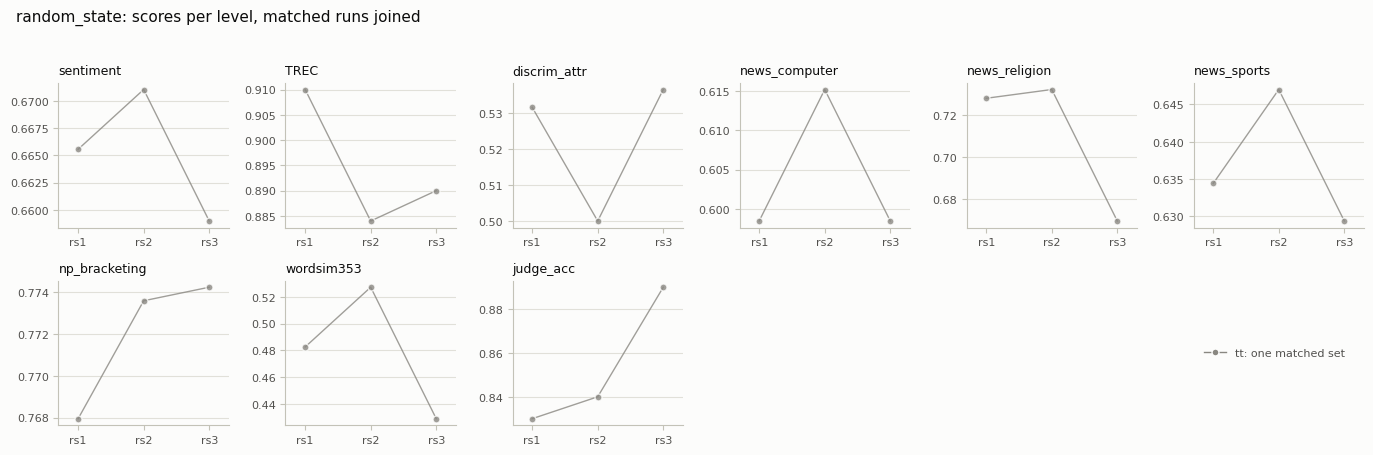

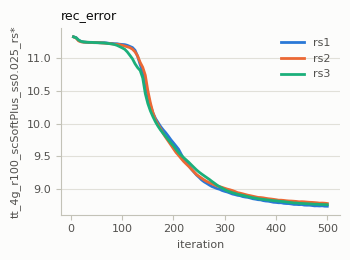

In [52]:
S_seed, R_seed, seed_noise = ce.seed_report(S, section2_results)

## 3. Our standard runs against comparable baselines

**Which runs.** The runs compared here were fixed in advance, not picked on the results: the TT 4-gram and the Tucker 3-gram at their standard settings (scSoftPlus, subsample 0.025, our 10k words), at the two latent ranks that the baselines have (`HEADLINE`, in the settings cell: r100 and r300).

**Which baselines.** A representative comparison has the same vocabulary and the same latent rank.

- Same vocabulary: every baseline was restricted to our 10k words. A baseline counts as sharing our vocabulary if it knows at least `VOCAB_MIN` of them.
- Same latent rank: our rank equals the number of dimensions of the baseline.

**Tests, per baseline**

- Downstream tasks: Wilcoxon signed-rank over the tasks.
- Judge accuracy: 2 × 2 chi-square (the CMH test with one stratum).
- Holm's correction over the baselines of a table. Δ = ours − baseline.

A coverage table follows each comparison.

**Power.** With 8 tasks the smallest Wilcoxon p is 2/2⁸. Holm over m baselines puts the smallest attainable downstream p at m · 2/2⁸. Where that is 0.05 or more, the downstream reading says "no power": read the Δ, not the test.

**Training data.** The training data differ, and no comparison equalises that: ours is FineWeb (1B tokens), GloVe is Wiki+Gigaword, word2vec is Google News (~100B), NNSE is ClueWeb09. The `data` column of 3.1 lists it.

### 3.1 Foundations

Per baseline: what it is, its training data, its latent rank, and how many of our words it knows.

In [53]:
foundations = ce.foundations(S)
baselines = foundations[~S.df['family'].isin(ce.OURS)]

(baselines.sort_values(['kind', 'latent_rank']).style
 .format('{:.0f}', subset=['latent_rank', 'words'], na_rep='–')
 .format('{:.0%}', subset=['of our words'], na_rep='–'))

,kind,data,latent_rank,words,of our words
model,,,,,
glove_100,dense,Wiki+Gigaword 2024,100,9987,100%
glove_300,dense,Wiki+Gigaword 2024,300,9987,100%
w2v,dense,Google News,300,–,–
nnse_300,interpretable: NNSE,ClueWeb09,300,9286,93%
nnse_1000,interpretable: NNSE,ClueWeb09,1000,9444,94%
polar_glove_k500,interpretable: POLAR,Wiki+Gigaword 2024 (GloVe),500,9987,100%
polar_w2v_k500,interpretable: POLAR,Google News (word2vec),500,9789,98%
sinr_bnc,interpretable: SINr,"BNC, lemmas only",1431,6004,60%
spine_glove,interpretable: SPINE,released vectors,1000,7941,79%


### 3.2 Same vocabulary, same latent rank

For each latent rank in `HEADLINE`, each of its runs is compared with the baselines of that latent rank that share our vocabulary: the r100 runs with `glove_100`; the r300 runs with `glove_300`, `w2v` and `nnse_300`.

In [54]:
T_same = {}  # our run -> its table of tests
for latent_rank, (headline_runs, matched) in ce.matched_baselines(S, HEADLINE, VOCAB_MIN).items():
    print(f'latent_rank {latent_rank}: {", ".join(headline_runs) or "-"} against {", ".join(matched) or "-"}')
    if not matched:
        continue
    for run in headline_runs:
        caption = f'latent_rank {latent_rank}: {run} against the baselines of that latent_rank on our words'
        T_same[run] = ce.versus(S, run, matched, caption=caption)

latent_rank 100: tt_4g_r100_scSoftPlus_ss0.025, tucker_3g_r100_scSoftPlus_ss0.025 against glove_100


,tt_4g_r100_scSoftPlus_ss0.025,glove_100,Δ vs glove_100
sentiment,0.666,0.754,-0.088
TREC,0.910,0.772,+0.138
discrim_attr,0.532,0.588,-0.056
news_computer,0.598,0.685,-0.086
news_religion,0.728,0.831,-0.103
news_sports,0.634,0.822,-0.187
np_bracketing,0.768,0.745,+0.023
wordsim353,0.483,0.496,-0.013
downstream_average,0.665,0.712,-0.047
judge_acc,0.830,0.440,+0.390


,,,downstream tasks,downstream mean Δ,downstream tasks better,downstream tasks worse,downstream effect,downstream p,downstream p (Holm),downstream reading,judge acc by level,judge acc Δ,judge acc p (Holm),judge acc reading
factor,test,levels,,,,,,,,,,,,
tt_4g_r100_scSoftPlus_ss0.025,vs,glove_100,8,-0.047,2,6,-0.500,0.2500,0.2500,no evidence,0.440 → 0.830,+0.390,0.0000,ours better


,tucker_3g_r100_scSoftPlus_ss0.025,glove_100,Δ vs glove_100
sentiment,0.686,0.754,-0.068
TREC,0.896,0.772,+0.124
discrim_attr,0.530,0.588,-0.058
news_computer,0.598,0.685,-0.086
news_religion,0.748,0.831,-0.084
news_sports,0.629,0.822,-0.192
np_bracketing,0.778,0.745,+0.033
wordsim353,0.465,0.496,-0.030
downstream_average,0.666,0.712,-0.045
judge_acc,0.900,0.440,+0.460


,,,downstream tasks,downstream mean Δ,downstream tasks better,downstream tasks worse,downstream effect,downstream p,downstream p (Holm),downstream reading,judge acc by level,judge acc Δ,judge acc p (Holm),judge acc reading
factor,test,levels,,,,,,,,,,,,
tucker_3g_r100_scSoftPlus_ss0.025,vs,glove_100,8,-0.045,2,6,-0.500,0.2500,0.2500,no evidence,0.440 → 0.900,+0.460,0.0000,ours better


latent_rank 300: tt_4g_r300_scSoftPlus_ss0.025, tucker_3g_r300_scSoftPlus_ss0.025 against glove_300, nnse_300


,tt_4g_r300_scSoftPlus_ss0.025,glove_300,nnse_300,Δ vs glove_300,Δ vs nnse_300
sentiment,0.692,0.759,0.705,-0.068,-0.013
TREC,0.904,0.796,0.814,+0.108,+0.090
discrim_attr,0.523,0.618,0.557,-0.095,-0.034
news_computer,0.650,0.746,0.710,-0.097,-0.060
news_religion,0.755,0.840,0.816,-0.085,-0.061
news_sports,0.663,0.861,0.862,-0.197,-0.198
np_bracketing,0.769,0.739,0.696,+0.030,+0.073
wordsim353,0.541,0.539,0.340,+0.002,+0.201
downstream_average,0.687,0.737,0.688,-0.050,-0.001
judge_acc,0.847,0.360,0.827,+0.487,+0.020


,tucker_3g_r300_scSoftPlus_ss0.025,glove_300,nnse_300,Δ vs glove_300,Δ vs nnse_300
sentiment,0.728,0.759,0.705,-0.031,+0.023
TREC,0.908,0.796,0.814,+0.112,+0.094
discrim_attr,0.545,0.618,0.557,-0.072,-0.012
news_computer,0.595,0.746,0.710,-0.152,-0.116
news_religion,0.780,0.840,0.816,-0.060,-0.036
news_sports,0.653,0.861,0.862,-0.207,-0.209
np_bracketing,0.768,0.739,0.696,+0.029,+0.072
wordsim353,0.517,0.539,0.340,-0.022,+0.177
downstream_average,0.687,0.737,0.688,-0.051,-0.001
judge_acc,0.873,0.360,0.827,+0.513,+0.047


### 3.3 Interpretable methods

The two r300 runs of `HEADLINE` against POLAR, SPINE, SPOWV, NNSE and SINr, on our words. Here the latent rank is *not* matched.

Read the coverage table and section 3.1 before interpreting a difference:

- Latent rank and coverage differ. SPINE and SPOWV have 1000 dimensions. SINr has 1431 dimensions and only lemmas of nouns, verbs and adjectives (about 6000 of our words).
- With 9 baselines the downstream test has no power (Holm floor 0.07): read the Δ.
- The judge ranks every dimension of a method over our words. Section 1.1 gives each method's interval and its `short dims`.
- `polar_w2v_k500` has no judge score.

In [55]:
interpretable = list(baselines.index[baselines['kind'].str.startswith('interpretable')])

T_interp = {}  # our run -> its table of tests
for run in HEADLINE[300]:
    if run in S.df.index:
        caption = f'{run} against the interpretable methods, any latent_rank, on our words'
        T_interp[run] = ce.versus(S, run, interpretable, caption=caption)

,tt_4g_r300_scSoftPlus_ss0.025,polar_glove_k500,polar_w2v_k500,spine_glove,spine_w2v,spowv_glove,spowv_w2v,nnse_300,nnse_1000,sinr_bnc,Δ vs polar_glove_k500,Δ vs polar_w2v_k500,Δ vs spine_glove,Δ vs spine_w2v,Δ vs spowv_glove,Δ vs spowv_w2v,Δ vs nnse_300,Δ vs nnse_1000,Δ vs sinr_bnc
sentiment,0.692,0.758,0.772,0.748,0.769,0.754,0.783,0.705,0.740,0.726,-0.066,-0.080,-0.057,-0.077,-0.062,-0.091,-0.013,-0.048,-0.034
TREC,0.904,0.786,0.812,0.886,0.914,0.794,0.800,0.814,0.914,0.786,+0.118,+0.092,+0.018,-0.010,+0.110,+0.104,+0.090,-0.010,+0.118
discrim_attr,0.523,0.603,0.598,0.605,0.650,0.606,0.626,0.557,0.588,0.646,-0.080,-0.075,-0.082,-0.127,-0.083,-0.103,-0.034,-0.065,-0.123
news_computer,0.650,0.662,0.721,0.777,0.772,0.766,0.816,0.710,0.781,0.752,-0.012,-0.071,-0.127,-0.122,-0.116,-0.166,-0.060,-0.131,-0.102
news_religion,0.755,0.796,0.835,0.796,0.808,0.828,0.821,0.816,0.826,0.816,-0.042,-0.081,-0.042,-0.053,-0.074,-0.067,-0.061,-0.071,-0.061
news_sports,0.663,0.798,0.864,0.877,0.888,0.877,0.893,0.862,0.864,0.809,-0.134,-0.201,-0.214,-0.225,-0.214,-0.230,-0.198,-0.201,-0.146
np_bracketing,0.769,0.732,0.740,0.745,0.756,0.698,0.713,0.696,0.721,0.709,+0.037,+0.029,+0.024,+0.013,+0.071,+0.057,+0.073,+0.048,+0.060
wordsim353,0.541,0.578,0.517,0.650,0.635,0.675,0.604,0.340,0.592,0.550,-0.038,+0.024,-0.110,-0.094,-0.134,-0.064,+0.201,-0.051,-0.009
downstream_average,0.687,0.714,0.732,0.761,0.774,0.750,0.757,0.688,0.753,0.724,-0.027,-0.045,-0.074,-0.087,-0.063,-0.070,-0.001,-0.066,-0.037
judge_acc,0.847,0.562,0.546,0.731,0.795,0.394,0.467,0.827,0.874,0.475,+0.285,+0.301,+0.116,+0.052,+0.453,+0.380,+0.020,-0.027,+0.371


,tucker_3g_r300_scSoftPlus_ss0.025,polar_glove_k500,polar_w2v_k500,spine_glove,spine_w2v,spowv_glove,spowv_w2v,nnse_300,nnse_1000,sinr_bnc,Δ vs polar_glove_k500,Δ vs polar_w2v_k500,Δ vs spine_glove,Δ vs spine_w2v,Δ vs spowv_glove,Δ vs spowv_w2v,Δ vs nnse_300,Δ vs nnse_1000,Δ vs sinr_bnc
sentiment,0.728,0.758,0.772,0.748,0.769,0.754,0.783,0.705,0.740,0.726,-0.030,-0.044,-0.020,-0.041,-0.026,-0.054,+0.023,-0.012,+0.002
TREC,0.908,0.786,0.812,0.886,0.914,0.794,0.800,0.814,0.914,0.786,+0.122,+0.096,+0.022,-0.006,+0.114,+0.108,+0.094,-0.006,+0.122
discrim_attr,0.545,0.603,0.598,0.605,0.650,0.606,0.626,0.557,0.588,0.646,-0.058,-0.053,-0.059,-0.104,-0.061,-0.081,-0.012,-0.043,-0.101
news_computer,0.595,0.662,0.721,0.777,0.772,0.766,0.816,0.710,0.781,0.752,-0.067,-0.126,-0.183,-0.178,-0.171,-0.221,-0.116,-0.187,-0.157
news_religion,0.780,0.796,0.835,0.796,0.808,0.828,0.821,0.816,0.826,0.816,-0.017,-0.056,-0.017,-0.028,-0.049,-0.042,-0.036,-0.046,-0.036
news_sports,0.653,0.798,0.864,0.877,0.888,0.877,0.893,0.862,0.864,0.809,-0.144,-0.211,-0.224,-0.235,-0.224,-0.240,-0.209,-0.211,-0.156
np_bracketing,0.768,0.732,0.740,0.745,0.756,0.698,0.713,0.696,0.721,0.709,+0.036,+0.029,+0.023,+0.012,+0.070,+0.056,+0.072,+0.047,+0.059
wordsim353,0.517,0.578,0.517,0.650,0.635,0.675,0.604,0.340,0.592,0.550,-0.062,+0.000,-0.134,-0.118,-0.158,-0.088,+0.177,-0.075,-0.033
downstream_average,0.687,0.714,0.732,0.761,0.774,0.750,0.757,0.688,0.753,0.724,-0.027,-0.046,-0.074,-0.087,-0.063,-0.070,-0.001,-0.066,-0.037
judge_acc,0.873,0.562,0.546,0.731,0.795,0.394,0.467,0.827,0.874,0.475,+0.311,+0.327,+0.142,+0.078,+0.479,+0.406,+0.047,-0.001,+0.398


## 4. Scaling

Seconds per iteration, read from the runs' logs (`ce.iter_times`: `inspect_tucker.load_iter_times` over the resume chain). An iteration time is the device-synced time of the update and the error computation; it excludes the evaluation and the checkpointing done inside the loop. Runs shared GPUs and ran on different hardware, so read the times as rough.

1. **Overview.** Every run of ours, also the runs that the cuts of section 0 left out (`left out` gives the reason; empty = kept).
2. **Per factor.** For each factor of section 2, its matched sets (`ce.cost`), with `× first level` = the time relative to the first level of the set. This also takes the runs that the cuts left out: a time per iteration does not need a finished run.

In [56]:
T_time = ce.time_overview(S)
T_time.style.format({column: '{:.2f}' for column in ['s / iteration', 'mean', 'min', 'max']}, na_rep='–')

,family,ngram,rank,method,ss_frac,dims,tt_rank,random_state,reached,s / iteration,mean,min,max,iterations timed,left out
model,,,,,,,,,,,,,,,
tucker_3g_r100_countingLog_ss0.025,tucker,3,100,countingLog,0.025000,10000,0,1,500,0.17,0.17,0.15,0.24,499,
tucker_3g_r100_countingLogEps_ss0.025,tucker,3,100,countingLogEps,0.025000,10000,0,1,500,0.38,0.38,0.36,0.47,499,
tucker_3g_r100_scSoftPlus_ss0.025,tucker,3,100,scSoftPlus,0.025000,10000,0,1,500,0.38,0.38,0.36,0.45,499,
tucker_3g_r100_scSoftPlus_ss0.1,tucker,3,100,scSoftPlus,0.100000,10000,0,1,500,1.19,1.19,1.14,1.30,499,
tucker_3g_r200_scSoftPlus_ss0.025,tucker,3,200,scSoftPlus,0.025000,10000,0,1,500,1.21,1.23,1.18,1.38,499,
tt_4g_r100_countingLog_ss0.025,tt,4,100,countingLog,0.025000,10000,100,1,500,1.91,1.94,1.82,2.19,499,
tt_5g_r100_countingLog_ss0.025,tt,5,100,countingLog,0.025000,10000,100,1,500,2.34,2.33,2.22,2.57,499,
tt_6g_r100_countingLog_ss0.025,tt,6,100,countingLog,0.025000,10000,100,1,500,2.34,2.33,2.24,2.46,499,
tucker_3g_r300_scSoftPlus_ss0.025,tucker,3,300,scSoftPlus,0.025000,10000,0,1,500,3.01,3.06,2.89,3.45,499,


In [57]:
# the factors of section 2: 2.1 (family and bond dimension), then 2.2 to 2.6
SCALE_FACTORS = ['family', 'tt_rank', 'ss_frac', 'method', 'ngram', 'rank', 'dims']
T_scale = ce.cost_by_factor(S, SCALE_FACTORS)
T_scale.style.format({**COST_FORMAT, '× first level': '{:.2f}'}, na_rep='–')

## Appendix A. 200k-word vocabulary (quick test)

The analysis of section 2.6 on a second suite, `S_app`, in which the runs in `APPENDIX` are put back: the 200k-word run next to its 10k and 20k siblings. It is not part of the main results.

The caveats of 2.6 hold all the more: 200k words cover more of every task. A run that the judge has not scored has empty judge columns.

sweep: sweep_2026-09-30T172843.json (running)
methods: methods_2026-09-24T183147.json (dry-run)
  tt_4g_r100_scSoftPlus_ss1: left out: no checkpoint before the walltime stop (model file at iteration 30)
  not at the table's iteration count, named <model>_<iterations reached>: tucker_4g_r100_countingLogEps_ss0.025_200, tucker_4g_r100_scSoftPlus_ss0.025_d20000_155, tucker_4g_r100_scSoftPlus_ss0.025_rs2_195, tucker_4g_r100_scSoftPlus_ss0.025_rs3_185, tt_4g_r100_scSoftPlus_ss0.1_300, tt_4g_r1000_scSoftPlus_ss0.025_305, tt_4g_r100_scSoftPlus_ss0.025_tt300_400, tt_5g_r100_scSoftPlus_ss0.1_245, tt_5g_r300_scSoftPlus_ss0.025_400, tt_6g_r100_scSoftPlus_ss0.1_100, tt_6g_r100_countingLogEps_ss0.025_415, tt_6g_r200_scSoftPlus_ss0.025_275, tt_6g_r300_scSoftPlus_ss0.025_205
kept 26 of our runs and 12 baselines on our words (series latest); 15 rows left out, 12 *_full rows apart
judge: summary_2026-10-02T110542.csv; trials of 37 judged rows


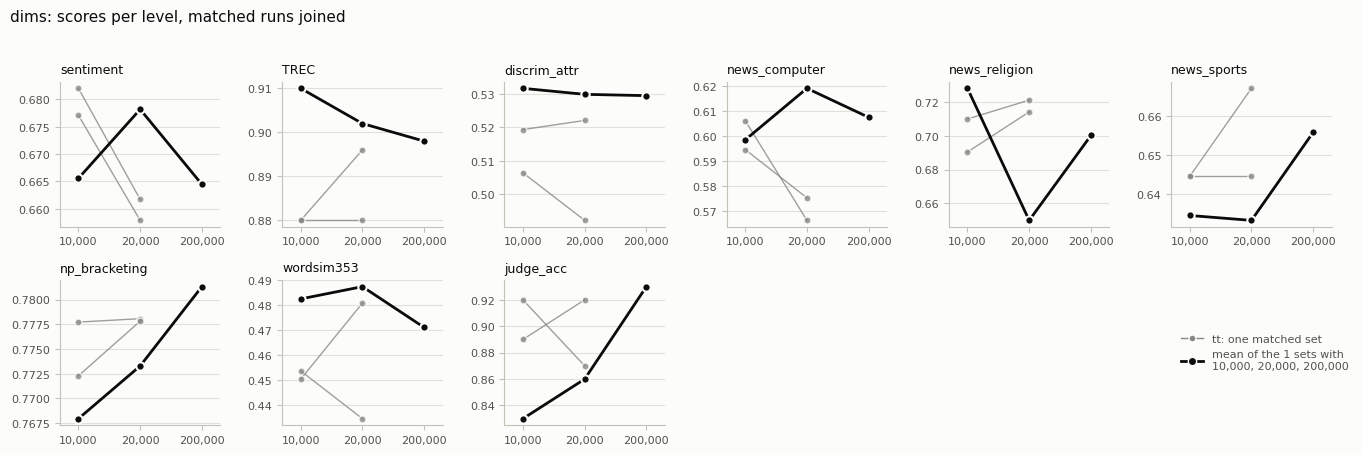

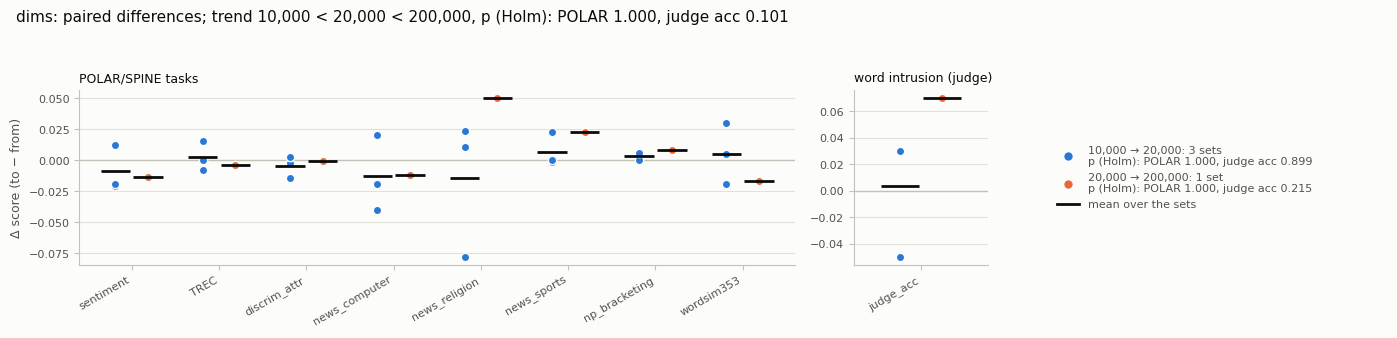

,sentiment,TREC,discrim_attr,news_computer,news_religion,news_sports,np_bracketing,wordsim353
"10,000 → 20,000",+0.048,+0.044,+0.285,+0.030,+0.030,+0.041,+0.038,+0.165
"20,000 → 200,000",+0.067,+0.081,+0.278,+0.045,+0.040,+0.062,+0.015,+0.071


In [58]:
S_app = ce.load(SERIES, min_iters=MIN_ITERS, exclude=EXCLUDE, skip=SKIP, judge_csv=JUDGE_CSV)
R_dims_app = ce.report(S_app, 'dims')
ce.coverage_shift(S_app, R_dims_app)

## Appendix B. The `best` series: the state that training's judge picked

Not used anywhere above.

**What the `best` series is.** During training, a small judge (Qwen3.5-2B, k = 5 top words) scores the model at every semantic check; the score is its accuracy times the diversity of the top words. The model file is overwritten whenever that score improves. The `best` series scores that model file instead of the last checkpoint.

**What is shown**

1. The same cuts as in section 0, applied to the `best` series, and the state check.
2. Per run, `downstream_average` and `judge_acc` of both series side by side. Δ = best − latest, with a Wilcoxon test over the runs.
3. The checks made during training for the runs of section 2.1: training's judge as raw accuracy, and SimLex.

In [59]:
S_best = ce.load('best', min_iters=MIN_ITERS, exclude=[*EXCLUDE, *APPENDIX], skip=SKIP, judge_csv=JUDGE_CSV)
display(ce.checks(S_best))
ce.series_compare(S, S_best)

best: best_2026-09-30T173300.json (running)
methods: methods_2026-09-24T183147.json (dry-run)
  tt_4g_r100_scSoftPlus_ss1: left out: no checkpoint before the walltime stop (model file at iteration 30)
  not at the table's iteration count, named <model>_<iterations reached>: tucker_4g_r100_countingLogEps_ss0.025_200, tucker_4g_r100_scSoftPlus_ss0.025_d20000_155, tucker_4g_r100_scSoftPlus_ss0.025_rs2_195, tucker_4g_r100_scSoftPlus_ss0.025_rs3_185, tt_4g_r100_scSoftPlus_ss0.1_300, tt_4g_r1000_scSoftPlus_ss0.025_305, tt_4g_r100_scSoftPlus_ss0.025_tt300_400, tt_5g_r100_scSoftPlus_ss0.1_245, tt_5g_r300_scSoftPlus_ss0.025_400, tt_6g_r100_scSoftPlus_ss0.1_100, tt_6g_r100_countingLogEps_ss0.025_415, tt_6g_r200_scSoftPlus_ss0.025_275, tt_6g_r300_scSoftPlus_ss0.025_205
kept 25 of our runs and 12 baselines on our words (series best); 16 rows left out, 12 *_full rows apart
judge: summary_2026-10-02T110542.csv; trials of 36 judged rows


,run,downstream,judge
model,,,


,downstream_average (latest),downstream_average (best),Δ downstream_average,judge_acc (latest),judge_acc (best),Δ judge_acc,file (latest),file (best)
run,,,,,,,,
tucker_3g_r100_scSoftPlus_ss0.025,0.666,0.670,+0.004,0.900,0.890,-0.010,500.pt,h100_kl_scSoftPlus_3D_10000d_shared012_100r_0p025ss_500i.pt
tucker_3g_r100_scSoftPlus_ss0.1,0.665,0.663,-0.003,0.880,0.850,-0.030,500.pt,h100_kl_scSoftPlus_3D_10000d_shared012_100r_0p1ss_500i.pt
tucker_3g_r100_scSoftPlus_ss1,0.663,0.663,+0.000,0.880,0.810,-0.070,500.pt,h100_kl_scSoftPlus_3D_10000d_shared012_100r_500i.pt
tucker_3g_r100_countingLog_ss0.025,0.615,0.634,+0.019,0.910,0.880,-0.030,500.pt,h100_kl_countingLog_3D_10000d_shared012_100r_0p025ss_500i.pt
tucker_3g_r100_countingLogEps_ss0.025,0.637,0.637,-0.000,0.850,0.850,+0.000,500.pt,h100_kl_countingLogEps_3D_10000d_shared012_100r_0p025ss_500i.pt
tucker_3g_r200_scSoftPlus_ss0.025,0.689,0.685,-0.004,0.885,0.885,+0.000,500.pt,h100_kl_scSoftPlus_3D_10000d_shared012_200r_0p025ss_500i.pt
tucker_3g_r300_scSoftPlus_ss0.025,0.687,0.692,+0.005,0.873,0.863,-0.010,500.pt,h100_kl_scSoftPlus_3D_10000d_shared012_300r_0p025ss_500i.pt
tucker_4g_r100_scSoftPlus_ss0.025,0.650,0.643,-0.007,0.810,0.820,+0.010,500.pt,h100_kl_scSoftPlus_4D_10000d_shared0123_100r_0p025ss_500i.pt
tucker_4g_r100_countingLog_ss0.025,0.637,0.632,-0.005,0.930,0.900,-0.030,500.pt,h100_kl_countingLog_4D_10000d_shared0123_100r_0p025ss_500i.pt


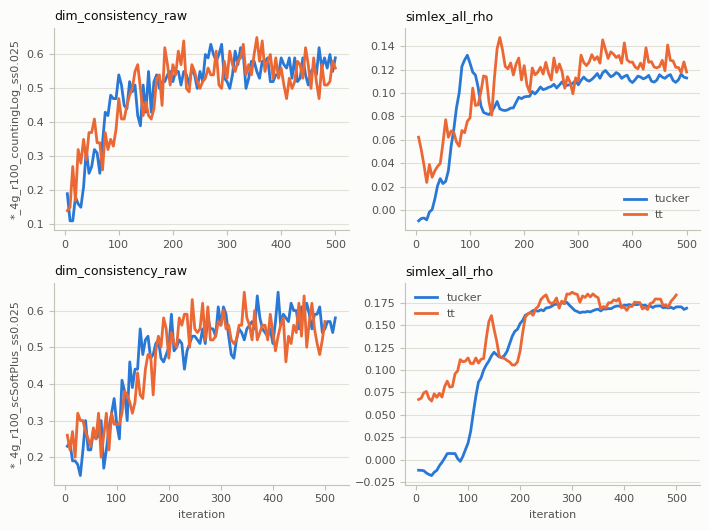

In [60]:
# The checks made during training, for the runs of 2.1 (Tucker vs TT, 4-gram):
# training's judge (raw accuracy) and SimLex
ce.plot_curves(S, ce.curve_groups(S, R_family), keys=ce.TRAINING_KEYS)